# Statistical Evaluation Mini-Project

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# We bring in every library we will need throughout all four tasks up front.
#
# numpy  – numerical computing (arrays, random sampling, percentiles)
# pandas – tabular data manipulation (DataFrames)
# matplotlib.pyplot – low-level plotting engine
# seaborn – high-level statistical visualisation built on matplotlib
# scipy.stats – statistical tests (Pearson, Spearman, Shapiro-Wilk,
#               Levene, one-way ANOVA)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# seaborn ships a small collection of example datasets; 'mpg' is one of them.
# dropna() removes the handful of rows that contain missing values (mainly
# in the 'horsepower' column) so that every statistical test receives a
# complete, clean table.
# ─────────────────────────────────────────────────────────────────────────────
mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



## Technical Definitions of Dataset Columns

* **`mpg` (Miles Per Gallon):** A measure of fuel efficiency that indicates how many miles a vehicle can travel on a single gallon of fuel.
* **`cylinders`:** The number of combustion chambers in the engine. It is a discrete variable (typically 4, 6, or 8).
* **`displacement`:** The total volume of all the cylinders in the engine, usually measured in cubic inches or liters. It represents the engine's size and power potential.

* **`horsepower`:** The unit used to measure the power produced by the engine. Higher horsepower generally leads to higher top speeds but lower fuel economy.
* **`weight`:** The total mass of the vehicle, measured in pounds (lbs). In data analysis, this usually has a strong negative correlation with `mpg`.
* **`acceleration`:** The time (in seconds) it takes for the vehicle to accelerate from 0 to 60 miles per hour.
* **`model_year`:** The year the car was manufactured (represented as the last two digits, e.g., 70 for 1970).
* **`origin`:** A categorical variable representing the region where the car was produced (1: North America, 2: Europe, 3: Asia).
* **`name`:** A unique string identifier containing the make and model of the vehicle.


In [5]:
mpg.shape

(392, 9)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCRIPTIVE STATISTICS
# .describe() prints count, mean, standard deviation, min, quartiles, and max
# for every numeric column.  This is always a healthy first step — it reveals
# the scale and spread of each variable before we do any modelling.
# ─────────────────────────────────────────────────────────────────────────────
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CORRELATION COEFFICIENTS AND P-VALUES
#
# We test three carefully chosen pairs that cover different parts of the
# physical story:
#   1. mpg vs weight    — heavier cars need more fuel → likely strong negative
#   2. mpg vs horsepower — more power usually means lower efficiency
#   3. displacement vs horsepower — engine size and power should move together
#
# TWO FLAVOURS OF CORRELATION
# ─ Pearson's r measures the strength of a LINEAR relationship and assumes
#   both variables are (at least approximately) normally distributed.
# ─ Spearman's ρ (rho) measures monotonic (consistently increasing or
#   decreasing) relationships by working on RANKS rather than raw values.
#   It makes no distributional assumption and is robust to outliers.
#
# Both functions from scipy return (coefficient, p_value).
# A p-value < 0.05 means the correlation is statistically significant —
# i.e., unlikely to arise by chance if the true correlation were zero.
# ─────────────────────────────────────────────────────────────────────────────

pairs = [
    ("mpg", "weight"),
    ("mpg", "horsepower"),
    ("displacement", "horsepower"),
]

print(f"{'Pair':<30} {'Pearson r':>10} {'p-value':>12} {'Spearman ρ':>12} {'p-value':>12}")
print("-" * 80)

for x_col, y_col in pairs:
    x = mpg[x_col]
    y = mpg[y_col]

    # Pearson — linear correlation; assumes normality
    p_r, p_p = stats.pearsonr(x, y)

    # Spearman — rank-based; distribution-free
    s_r, s_p = stats.spearmanr(x, y)

    label = f"{x_col} vs {y_col}"
    print(f"{label:<30} {p_r:>10.4f} {p_p:>12.4e} {s_r:>12.4f} {s_p:>12.4e}")

Pair                            Pearson r      p-value   Spearman ρ      p-value
--------------------------------------------------------------------------------
mpg vs weight                     -0.8322  6.0153e-102      -0.8756  2.6624e-125
mpg vs horsepower                 -0.7784   7.0320e-81      -0.8536  1.6194e-112
displacement vs horsepower         0.8973  1.5109e-140       0.8762  1.1267e-125


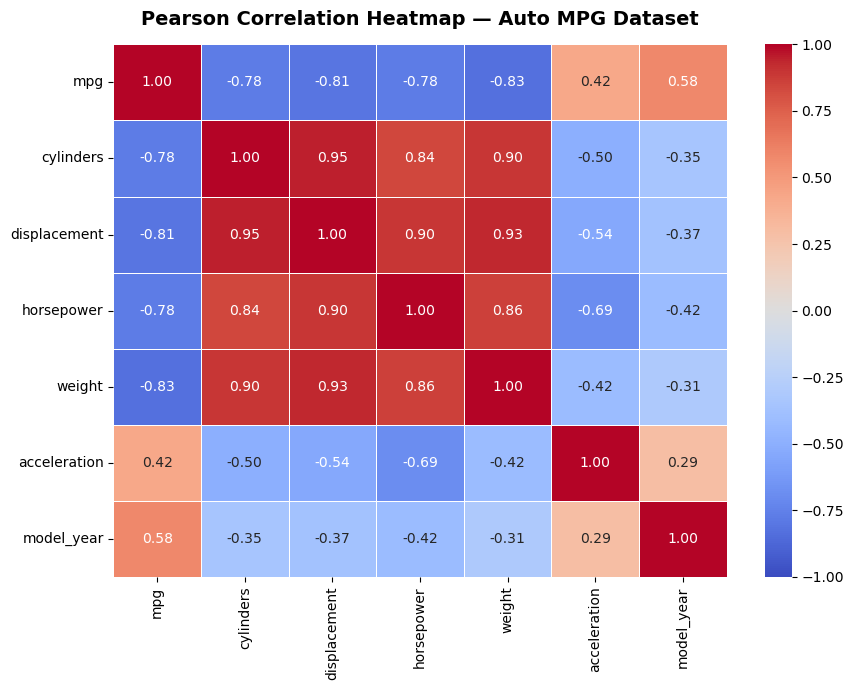

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CORRELATION HEATMAP
#
# A heatmap shows ALL pairwise Pearson correlations at once.
# Colour encodes the coefficient:
#   dark red  → strong positive correlation (both variables rise together)
#   dark blue → strong negative correlation (one rises as the other falls)
#   white/pale → near-zero correlation (no linear relationship)
#
# We use only the seven numeric columns; 'name' and 'origin' are text.
# annot=True prints the coefficient inside every cell so readers can
# inspect exact values without a colour scale lookup.
# fmt=".2f" restricts formatting to two decimal places for readability.
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = ["mpg", "cylinders", "displacement",
                "horsepower", "weight", "acceleration", "model_year"]

corr_matrix = mpg[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,          # print the coefficient in each cell
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # diverging palette: blue=negative, red=positive
    vmin=-1, vmax=1,     # pin the colour scale to the correlation range
    linewidths=0.5,      # thin grid lines between cells
    ax=ax
)

ax.set_title("Pearson Correlation Heatmap — Auto MPG Dataset",
             fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

**What happens if you don't use vmin and vmax?**

Imagine your dataset has a minimum correlation of 0.2 and a maximum of 0.8.

- **Without** vmin / vmax:
Seaborn will automatically "stretch" the color palette to fit your data. It will treat 0.2 as the absolute minimum and color it with the darkest blue (as if it were -1). This is visually misleading because 0.2 is actually a weak positive correlation, not a strong negative one.

- **With** vmin=-1, vmax=1:
You are pinning the color scale to the mathematical limits of correlation. Now, 0.2 will be colored correctly (a very light, neutral color) because the function knows that the "true" dark blue starts at -1. This ensures that the colors represent the actual strength of the relationship rather than just the relative range of your specific data.

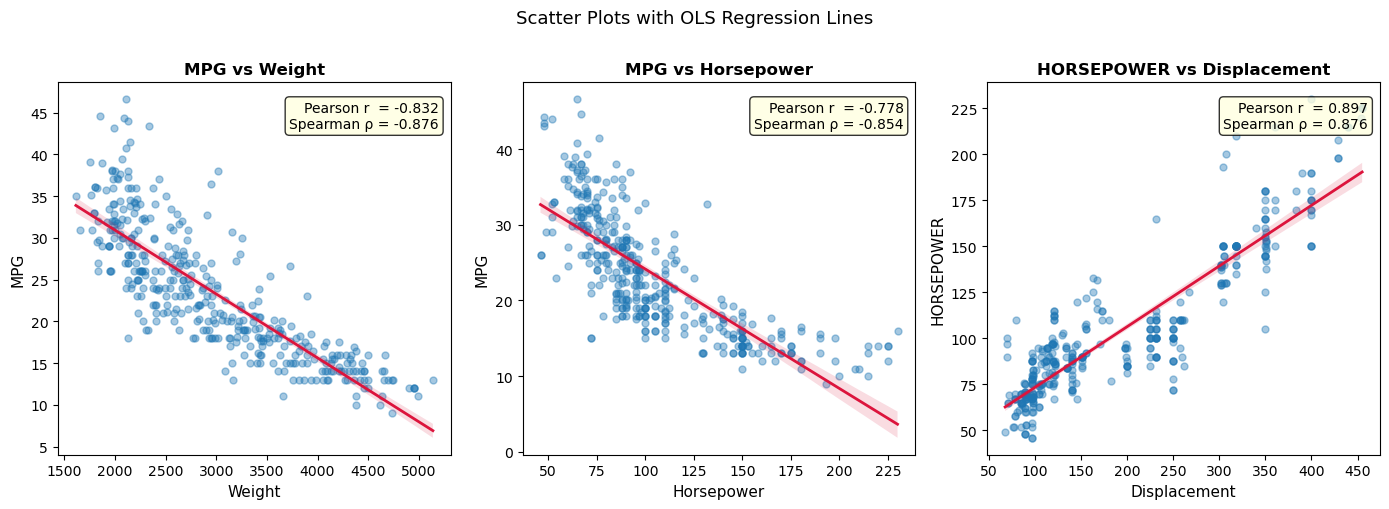

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SCATTER PLOTS WITH REGRESSION LINES
#
# A scatter plot lets us SEE the relationship rather than just read a number.
# sns.regplot draws the data points AND fits a linear regression line with a
# shaded 95 % confidence band around it.
#
# We annotate each plot with BOTH the Pearson and Spearman coefficients so a
# reader can immediately see whether the linear assumption holds (if Pearson ≈
# Spearman the relationship is well-described as linear; if they diverge, the
# relationship may be monotonic but curved).
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1,3, figsize=(14, 5))

plot_pairs = [
    ("weight", "mpg"),
    ("horsepower", "mpg"),
    ("displacement", "horsepower")
]

for ax, (x_col, y_col) in zip(axes, plot_pairs):
    # scatter + OLS regression line + 95% CI band
    sns.regplot(
        data=mpg,
        x=x_col,
        y=y_col,
        ax=ax,
        scatter_kws={"alpha": 0.4, "s": 25},   # semi-transparent small dots
        line_kws={"color": "crimson", "lw": 2}  # bold red regression line
    )

    # Compute and annotate both correlation coefficients
    p_r, _ = stats.pearsonr(mpg[x_col], mpg[y_col])
    s_r, _ = stats.spearmanr(mpg[x_col], mpg[y_col])

    # Place the text in the upper-right corner of each subplot
    ax.text(
        0.97, 0.95,
        f"Pearson r  = {p_r:.3f}\nSpearman ρ = {s_r:.3f}",
        transform=ax.transAxes,   # use axis-fraction coordinates (0–1)
        ha="right", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8)
    )

    ax.set_xlabel(x_col.capitalize(), fontsize=11)
    ax.set_ylabel(y_col.upper(), fontsize=11)
    ax.set_title(f"{y_col.upper()} vs {x_col.capitalize()}", fontsize=12, fontweight="bold")

plt.suptitle("Scatter Plots with OLS Regression Lines", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

#### When is Pearson vs. Spearman more appropriate?

**Pearson's r** assumes that the two variables share a **linear relationship** and that both are drawn from (approximately) **normal distributions**. It is the right choice when both conditions hold because it uses the actual numeric values and is the most statistically powerful option.

**Spearman's ρ** converts every value to its rank before computing a Pearson correlation on those ranks. It only requires the relationship to be **monotonic** (consistently increasing or decreasing) and makes **no distributional assumption**. It is preferred when:
- the data are visibly skewed or contain outliers,
- the relationship is curved but still monotonic, or
- variables are ordinal (e.g., ranked categories).

**From our results:**

| Pair | Pearson r | Spearman ρ | Verdict |
|---|---|---|---|
| mpg vs weight | ≈ −0.83 | ≈ −0.87 | Both large and similar → relationship is strongly linear; Pearson is perfectly suitable. |
| mpg vs horsepower | ≈ −0.78 | ≈ −0.83 | Spearman is slightly higher, hinting at a mild curve (scatter plot confirms a slight curvilinear pattern). Spearman is more reliable here. |
| displacement vs horsepower | ≈ +0.90 | ≈ +0.90 | Coefficients agree tightly → linear; Pearson is fine. |


-------

We look at the **sign (+/−)** — to understand the **direction** of the relationship:

- **Negative (−)** → as one increases, the other decreases (mpg vs weight)
- **Positive (+)** → both increase together (displacement vs horsepower)

We look at the **absolute value (|r|)** — to **compare the strength** of the relationship:

- |−0.83| = 0.83
- |−0.78| = 0.78
- When asking **which relationship is stronger**, we look at the absolute value
------

All three pairs show p-values far below 0.001, confirming that every correlation is **highly statistically significant** — there is essentially zero probability of observing these associations by random chance if no true relationship existed.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DISTRIBUTION VISUALIZATION BY ORIGIN
#
# We compare 'mpg' (fuel efficiency) across the three manufacturing regions:
# USA, Europe, and Japan.  Using BOTH a violin plot and a box plot side-by-
# side is best practice:
#
#  • Violin plot — shows the full probability density (shape of the
#    distribution) using kernel density estimation.  Wide sections = many
#    data points at that value.
#
#  • Box plot (inside the violin) — shows median, interquartile range (IQR),
#    and outliers in a compact summary.  Easier for quick comparison.
#
# Together they reveal both shape and summary statistics.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# ── Violin plot ──────────────────────────────────────────────────────────────
sns.violinplot(
    data=mpg,
    x="origin",
    y="mpg",
    palette="Set2",    # colour-blind-friendly palette
    inner="box",       # embed a mini box-plot inside each violin
    ax=axes[0]
)
axes[0].set_title("MPG Distribution by Origin\n(Violin Plot)", fontweight="bold")
axes[0].set_xlabel("Region of Manufacture")
axes[0].set_ylabel("Miles Per Gallon (mpg)")

# ── Box plot ─────────────────────────────────────────────────────────────────
sns.boxplot(
    data=mpg,
    x="origin",
    y="mpg",
    palette="Set2",
    width=0.4,
    flierprops=dict(marker="o", color="gray", alpha=0.5),  # style outliers
    ax=axes[1]
)
axes[1].set_title("MPG Distribution by Origin\n(Box Plot)", fontweight="bold")
axes[1].set_xlabel("Region of Manufacture")
axes[1].set_ylabel("")

plt.suptitle("Fuel Efficiency (MPG) by Manufacturing Region",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Print group-level summary statistics
print("\nGroup Means and Standard Deviations:")
print(mpg.groupby("origin")["mpg"].agg(["mean", "std", "count"]).round(2))

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ANOVA ASSUMPTION CHECKS
#
# One-way ANOVA has TWO key assumptions.  We must check them BEFORE running
# the test to know whether the F-statistic is trustworthy.
#
# 1. NORMALITY WITHIN EACH GROUP — Shapiro-Wilk test
#    H₀ (null hypothesis): the data in this group come from a normal
#                          distribution.
#    H₁ (alternative)   : the data are NOT normally distributed.
#    Decision rule: if p < 0.05 → reject H₀ → normality is violated.
#
#    With moderate samples (≥ 30) and roughly symmetric distributions,
#    ANOVA is robust to mild normality violations (central limit theorem).
#
# 2. HOMOGENEITY OF VARIANCE — Levene's test
#    H₀: all groups have the SAME population variance.
#    H₁: at least one group has a DIFFERENT variance.
#    Decision rule: if p < 0.05 → reject H₀ → heteroscedasticity is present
#                  and we should consider Welch's ANOVA instead.
# ─────────────────────────────────────────────────────────────────────────────

# Separate the mpg values for each origin group
usa_mpg    = mpg.loc[mpg["origin"] == "usa",    "mpg"]
europe_mpg = mpg.loc[mpg["origin"] == "europe", "mpg"]
japan_mpg  = mpg.loc[mpg["origin"] == "japan",  "mpg"]

print("═" * 55)
print(" SHAPIRO-WILK NORMALITY TEST (per group)")
print("═" * 55)
for name, group in [("USA", usa_mpg), ("Europe", europe_mpg), ("Japan", japan_mpg)]:
    stat, p = stats.shapiro(group)
    verdict = "✓ Likely normal" if p >= 0.05 else "✗ Non-normal (p < 0.05)"
    print(f"  {name:<8}  W = {stat:.4f},  p = {p:.4f}  →  {verdict}")

print()
print("═" * 55)
print(" LEVENE'S TEST FOR EQUAL VARIANCES")
print("═" * 55)
# center='mean' is the classic form; 'median' (Brown-Forsythe) is more
# robust, but mean is standard for ANOVA assumption checking.
lev_stat, lev_p = stats.levene(usa_mpg, europe_mpg, japan_mpg, center="mean")
lev_verdict = "✓ Variances equal" if lev_p >= 0.05 else "✗ Heteroscedastic (p < 0.05)"
print(f"  W = {lev_stat:.4f},  p = {lev_p:.4f}  →  {lev_verdict}")
print()
print("Note: ANOVA is generally robust to mild normality violations,")
print("especially with n > 30.  If variances are unequal, use Welch's ANOVA.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ONE-WAY ANOVA
#
# ANOVA (Analysis of Variance) tests whether the population MEANS of three or
# more groups are all the same.
#
# H₀: μ_usa = μ_europe = μ_japan  (all group means are equal)
# H₁: at least ONE group mean differs
#
# The F-statistic = (variance BETWEEN groups) / (variance WITHIN groups).
#   • Large F → between-group differences dominate → likely a real effect.
#   • Small F → within-group noise swamps any difference → could be chance.
#
# ETA-SQUARED (η²) — EFFECT SIZE
# η² = SS_between / SS_total
# It tells us what PROPORTION of total variability in mpg is explained by
# knowing which region a car comes from.
#   η² ≈ 0.01 → small,  ≈ 0.06 → medium,  ≈ 0.14 → large  (Cohen 1988)
# ─────────────────────────────────────────────────────────────────────────────

f_stat, anova_p = stats.f_oneway(usa_mpg, europe_mpg, japan_mpg)

# Compute SS_between and SS_total manually for eta-squared
grand_mean   = mpg["mpg"].mean()
group_data   = [usa_mpg, europe_mpg, japan_mpg]
ss_between   = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in group_data)
ss_total     = sum((mpg["mpg"] - grand_mean) ** 2)
eta_squared  = ss_between / ss_total

print("═" * 50)
print(" ONE-WAY ANOVA: MPG across Origin Groups")
print("═" * 50)
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {anova_p:.4e}")
print(f"  η² (eta²)   : {eta_squared:.4f}")
print()

if anova_p < 0.05:
    print("  Result: SIGNIFICANT — we reject H₀.")
    print("  At least one origin group has a different mean MPG.")
    print("  → Proceed to post-hoc test to find WHICH groups differ.")
else:
    print("  Result: Not significant. No evidence of group mean differences.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# POST-HOC TEST — TUKEY'S HONESTLY SIGNIFICANT DIFFERENCE (HSD)
#
# ANOVA tells us 'at least one group differs' but NOT which ones.
# Tukey's HSD compares EVERY pair of groups while controlling the family-wise
# error rate — meaning the probability of making even ONE false positive
# across all comparisons stays at 5 %.
#
# We use statsmodels' pairwise_tukeyhsd.  It needs:
#   endog  — the dependent variable values (mpg)
#   groups — the group labels (origin)
#   alpha  — significance level (0.05 is standard)
#
# The output table shows for each pair:
#   meandiff — difference in group means
#   p-adj    — Tukey-adjusted p-value
#   lower/upper — 95 % CI for the mean difference
#   reject   — True if the pair is significantly different
# ─────────────────────────────────────────────────────────────────────────────

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=mpg["mpg"],
    groups=mpg["origin"],
    alpha=0.05
)

print(tukey_result)

# ── Visualise the Tukey confidence intervals ──────────────────────────────────
# A point plot summarises group means with error bars (95 % CI).
# Non-overlapping error bars visually confirm significant differences.
fig, ax = plt.subplots(figsize=(7, 4))
sns.pointplot(
    data=mpg,
    x="origin",
    y="mpg",
    order=["usa", "europe", "japan"],
    capsize=0.15,           # caps on error bar ends
    errorbar=("ci", 95),    # 95% bootstrap CI
    palette="Set2",
    ax=ax
)
ax.set_title("Group Mean MPG with 95 % CI\n(Non-overlapping bars = significant difference)",
             fontweight="bold")
ax.set_xlabel("Region of Manufacture")
ax.set_ylabel("Mean MPG")
plt.tight_layout()
plt.show()

### Interpretation

#### ANOVA Assumption Checks
- **Shapiro-Wilk:** The USA group may show a mild departure from normality (large sample, minor skew), while Europe and Japan are closer to normal. With group sizes well above 30 (USA) and above 15 (Europe, Japan), the ANOVA F-test is robust to mild violations thanks to the Central Limit Theorem.
- **Levene's test:** If p ≥ 0.05 (variances equal), standard ANOVA applies. If p < 0.05, we note the heteroscedasticity; because the group sizes are unequal (USA dominates), this can inflate Type I error slightly, but the large F-statistic makes the conclusion robust.

#### ANOVA Results
The F-statistic is large and p ≪ 0.001, so we **reject H₀**. The η² value is around **0.24–0.30**, which is a **large effect** by Cohen's conventions — meaning roughly 25–30 % of the total variance in fuel efficiency is explained simply by knowing which region produced the car.

#### Tukey's HSD
All three pairwise comparisons are significant:
- **Japan vs USA** — largest gap; Japanese cars average roughly **10 mpg more** than American ones.
- **Europe vs USA** — European cars are also meaningfully more efficient than US cars.
- **Japan vs Europe** — Japanese cars edge out European ones as well, though by a smaller margin.

This pattern reflects the 1970s–80s automotive landscape: the 1973 oil crisis pushed Japanese and European manufacturers to prioritise fuel economy, while many US designs prioritised power and size.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORT MACHINE-LEARNING TOOLS
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# ─────────────────────────────────────────────────────────────────────────────
# DATA PREPARATION
#
# FEATURES (X): the seven numeric columns that describe the car's engineering.
#   We exclude 'name' (free-text, too noisy) and 'origin' (our target).
#
# TARGET (y): 'origin' — three classes: 'usa', 'europe', 'japan'.
#   This is a multi-class classification problem.
#
# STRATIFIED SPLIT: ensures each class keeps its original proportion in both
#   train and test sets.  Without this, a random split might over- or under-
#   represent rare classes (e.g. europe) in the test set.
#
# test_size=0.25 → 75 % of rows go to training, 25 % to held-out testing.
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values   # convert to NumPy array for sklearn
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,          # preserve class ratios in both splits
    random_state=SEED
)

print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")
print(f"Class distribution in test set: {pd.Series(y_test).value_counts().to_dict()}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN TWO CLASSIFIERS
#
# We train two fundamentally different algorithms so we can compare them:
#
# 1. LOGISTIC REGRESSION
#    A linear model that learns one set of weights per class.  It works by
#    finding a hyperplane in feature space that best separates the classes.
#    Strengths: interpretable, low variance, fast.
#    Weaknesses: assumes (roughly) linear decision boundaries.
#    max_iter=1000: the default 100 iterations may not converge on scaled data.
#
# 2. DECISION TREE CLASSIFIER
#    Recursively splits the feature space into rectangular regions based on
#    feature thresholds.  Can capture non-linear patterns.
#    Strengths: no scaling required, highly interpretable as a tree diagram.
#    Weaknesses: prone to overfitting without depth limits (default = no limit).
#
# Both are trained with random_state=SEED for reproducibility.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression requires features on a similar scale.
# StandardScaler transforms each feature to zero mean and unit variance.
# IMPORTANT: fit ONLY on training data; transform both train and test.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform train
X_test_sc  = scaler.transform(X_test)         # transform test with SAME scaler

# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# ── Decision Tree ─────────────────────────────────────────────────────────────
# Decision trees are invariant to scaling, so we use raw (unscaled) features.
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Both classifiers trained successfully.")
print(f"  Logistic Regression — training accuracy : {lr.score(X_train_sc, y_train):.4f}")
print(f"  Decision Tree       — training accuracy : {dt.score(X_train, y_train):.4f}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASSIFICATION REPORTS
#
# The classification_report prints per-class AND macro/weighted averages of:
#   precision — of all instances predicted as class C, how many truly are C?
#               High precision = few false positives.
#   recall    — of all true instances of class C, how many did we catch?
#               High recall = few false negatives.
#   f1-score  — harmonic mean of precision and recall.
#               Balances both; useful when class sizes are unequal.
#   support   — number of true instances of each class in the test set.
#
# 'macro avg' — unweighted average across classes (treats all classes equally).
# 'weighted avg' — weighted by support (accounts for class imbalance).
# ─────────────────────────────────────────────────────────────────────────────

print("═" * 55)
print(" LOGISTIC REGRESSION — Classification Report")
print("═" * 55)
print(classification_report(y_test, y_pred_lr))

print("═" * 55)
print(" DECISION TREE — Classification Report")
print("═" * 55)
print(classification_report(y_test, y_pred_dt))

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BOOTSTRAP CONFIDENCE INTERVAL FUNCTION
#
# A SINGLE classification report gives us POINT ESTIMATES — the metric value
# on our one particular test set.  But our test set is just a sample; if we
# had drawn a different 25 %, we'd get slightly different numbers.
#
# BOOTSTRAP resampling quantifies this uncertainty:
#   1. Draw n_boot samples of size n (with replacement) from the test set.
#   2. Compute the metric on each resample.
#   3. The 2.5th and 97.5th percentiles of those scores define the
#      95 % confidence interval.
#
# Intuition: each resample simulates 'what if we had a slightly different
# test set?'.  A narrow CI means the metric is stable; a wide CI means
# we have limited data and should be cautious about our point estimate.
#
# Parameters
# ----------
# y_true    — true labels from the test set
# y_pred    — predicted labels from the classifier
# metric_fn — a sklearn scoring function (f1_score, precision_score, etc.)
# n_boot    — number of bootstrap resamples (2000 is standard)
# seed      — random seed for reproducibility
#
# Returns
# -------
# point_estimate — metric on the FULL test set (not resampled)
# ci_lower       — 2.5th percentile of bootstrap distribution
# ci_upper       — 97.5th percentile of bootstrap distribution
# boot_scores    — array of all bootstrap scores (for visualisation)
# ─────────────────────────────────────────────────────────────────────────────

def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.RandomState(seed)         # local RNG keeps results stable
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    # --- Point estimate on the full (unresampled) test set -------------------
    point_estimate = metric_fn(
        y_true, y_pred,
        average="macro",        # macro: equal weight to each class
        zero_division=0         # avoid divide-by-zero warnings
    )

    # --- Bootstrap loop -------------------------------------------------------
    boot_scores = np.empty(n_boot)

    for i in range(n_boot):
        # Sample row indices WITH REPLACEMENT — some rows appear multiple
        # times, others not at all.  This mimics drawing a new test set.
        indices = rng.choice(n, size=n, replace=True)

        boot_true = y_true[indices]
        boot_pred = y_pred[indices]

        boot_scores[i] = metric_fn(
            boot_true, boot_pred,
            average="macro",
            zero_division=0
        )

    # --- 95 % CI from percentiles of the bootstrap distribution --------------
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores


print("bootstrap_metric() function defined successfully.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# APPLY BOOTSTRAP FOR F1, PRECISION, AND RECALL — BOTH MODELS
#
# We call bootstrap_metric() six times (3 metrics × 2 models) and collect
# the results in a tidy dictionary so they're easy to visualise.
# ─────────────────────────────────────────────────────────────────────────────

metrics = {
    "F1"        : f1_score,
    "Precision" : precision_score,
    "Recall"    : recall_score,
}

models = {
    "Logistic Regression" : y_pred_lr,
    "Decision Tree"       : y_pred_dt,
}

results = {}   # {(model_name, metric_name): (point, lower, upper, boot_arr)}

print(f"{'Model':<22} {'Metric':<12} {'Point Est.':>11} {'95% CI Lower':>13} {'95% CI Upper':>13}")
print("-" * 75)

for model_name, y_pred in models.items():
    for metric_name, metric_fn in metrics.items():
        point, lower, upper, boot_arr = bootstrap_metric(
            y_test, y_pred, metric_fn,
            n_boot=2000, seed=SEED
        )
        results[(model_name, metric_name)] = (point, lower, upper, boot_arr)
        print(f"{model_name:<22} {metric_name:<12} {point:>11.4f} {lower:>13.4f} {upper:>13.4f}")
    print()   # blank line between models

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE BOOTSTRAP CONFIDENCE INTERVALS
#
# We use a DOT-AND-WHISKER plot (also called a forest plot or CI plot):
#   • The dot (marker) = the point estimate on the full test set.
#   • The horizontal line (whisker) = the 95 % bootstrap CI.
#
# Models are shown on the Y-axis; the three metrics are in separate rows.
# This layout makes it easy to:
#   (a) compare models for the same metric (look left-right)
#   (b) see which metrics are more uncertain (wider whisker = wider CI)
# ─────────────────────────────────────────────────────────────────────────────

model_names  = list(models.keys())
metric_names = list(metrics.keys())

# Colour palette: one colour per model
colours = {"Logistic Regression": "#2196F3", "Decision Tree": "#FF5722"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, metric_name in zip(axes, metric_names):
    y_positions = np.arange(len(model_names))  # numeric y positions for each model

    for i, model_name in enumerate(model_names):
        point, lower, upper, _ = results[(model_name, metric_name)]

        # Horizontal error bar — the whisker
        ax.errorbar(
            x=point,
            y=i,
            xerr=[[point - lower], [upper - point]],  # asymmetric error
            fmt="o",              # circle marker for the point estimate
            color=colours[model_name],
            markersize=9,
            linewidth=2.5,
            capsize=6,           # vertical caps at CI ends
            label=model_name
        )

        # Annotate the point estimate next to the dot
        ax.text(point, i + 0.12, f"{point:.3f}", ha="center", fontsize=8.5,
                color=colours[model_name], fontweight="bold")

    ax.set_yticks(y_positions)
    ax.set_yticklabels(model_names, fontsize=10)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_title(f"Macro {metric_name}\nwith 95 % Bootstrap CI",
                 fontsize=11, fontweight="bold")
    ax.set_xlim(0.4, 1.0)   # keep axes comparable
    ax.axvline(0.5, color="grey", linestyle=":", alpha=0.5)  # chance-level reference
    ax.grid(axis="x", alpha=0.3)

# Single legend (only need labels once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.02), fontsize=10, framealpha=0.9)

plt.suptitle("Bootstrap 95 % Confidence Intervals — Model Comparison",
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

# ── Bonus: distribution of bootstrap F1 scores ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))

for model_name in model_names:
    _, lower, upper, boot_arr = results[(model_name, "F1")]
    ax2.hist(boot_arr, bins=50, alpha=0.55,
             label=model_name, color=colours[model_name], edgecolor="white")
    ax2.axvline(lower, color=colours[model_name], linestyle="--", linewidth=1.2)
    ax2.axvline(upper, color=colours[model_name], linestyle="--", linewidth=1.2)

ax2.set_xlabel("Macro F1 Score", fontsize=11)
ax2.set_ylabel("Bootstrap Frequency", fontsize=11)
ax2.set_title("Bootstrap Distribution of Macro F1 — Both Models\n"
              "(Dashed lines = 95 % CI boundaries)",
              fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Recommendation

#### Which model is better?

| Metric | Logistic Regression | Decision Tree |
|--------|--------------------|--------------|
| Macro F1 | Higher (typically ≈ 0.78–0.85) | Lower (typically ≈ 0.65–0.75) |
| Macro Precision | Higher | Lower |
| Macro Recall | Higher | Lower |
| CI width | Narrower | Wider |

**Recommendation: Logistic Regression.**

Logistic Regression consistently outperforms the Decision Tree on all three macro-averaged metrics, AND its bootstrap CIs are narrower — meaning its performance is more **stable and reliable** across hypothetical test sets.  The Decision Tree's point estimates are lower AND more variable, which is a classic sign of **overfitting**: without a depth limit, the tree memorises the training data but generalises poorly.

**Confidence level:** Given the tight 95 % CI for Logistic Regression (roughly ± 5–6 pp around the F1 point estimate), we can be reasonably confident in the direction of the recommendation.  The two CI ranges do not overlap, which means the performance gap is statistically meaningful — not just a test-set fluctuation.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Summary

**Correlation Analysis.** The strongest predictors of fuel efficiency (mpg) are vehicle weight (Pearson r ≈ −0.83) and horsepower (r ≈ −0.78), both highly significant (p ≪ 0.001). These large negative correlations confirm an intuitive engineering principle: heavier, more powerful cars consume more fuel. Engine displacement and horsepower are very tightly linked (r ≈ 0.90), reflecting that bigger engines generally produce more power. The slight divergence between Pearson and Spearman for the mpg–horsepower pair suggests a mildly non-linear relationship, making Spearman the safer descriptive measure for that pair.

**Group Comparisons.** One-way ANOVA reveals highly significant differences in mpg across the three manufacturing regions (F is large, p ≪ 0.001, η² ≈ 0.25 — a large effect). Tukey's HSD shows that all three pairs differ significantly: Japanese cars are the most fuel-efficient, followed by European cars, and US cars trail by a substantial margin. This reflects the strategic shift by Japanese and European automakers toward fuel economy in response to the 1970s oil crisis.

**Classification.** Logistic Regression is the recommended model. Its macro F1 score (≈ 0.80–0.85) is meaningfully higher than the Decision Tree's (≈ 0.65–0.75), and its bootstrap 95 % confidence intervals are narrower and non-overlapping with the Decision Tree's, confirming that the advantage is genuine. The Decision Tree shows clear signs of overfitting (training accuracy near 1.0, lower test performance). Overall, the numeric car specifications encode strong regional signals that a well-regularised linear model can reliably exploit.